# Diffusivity–density classification: distance from the PPPS identity line

This notebook reproduces the per-condition diffusivity–density analysis used for the publication and replaces an ad-hoc distance-from-line criterion with a formal hypothesis test.

## Analysis definition

Each cell contributes one point $(x,y)$,

$$
x = \frac{D_f-D_b}{D_n-D_b},
\qquad
y = \frac{\rho_n}{\rho_f}=e^{-\Delta U},
$$

where $D_f$ and $D_n$ are the focus and nucleoplasmic diffusion coefficients, $D_b$ is the baseline diffusion coefficient, and $\Delta U$ is the density-derived potential difference. The PPPS model predicts the identity relation $y=x$.

We quantify the signed log-space gap from this line as

$$
g = \ln x - \ln y = \Delta U - \Delta U_{\mathrm{PPPS}} \quad [k_BT].
$$

Thus:

- $g=0$: point lies on the PPPS identity line;
- $g>0$: point lies below the line and has excess binding energy beyond that explained by the diffusivity contrast.

The primary statistical test is a **one-sample, one-sided $t$-test** of $H_0:\langle g\rangle=0$ against $H_1:\langle g\rangle>0$, performed separately for each condition. Holm correction controls the family-wise error rate across the five conditions. A Wilcoxon signed-rank test and bootstrap confidence interval are reported as robustness checks.

## Reproducibility and expected repository layout

Run this notebook from the repository root with the following files/directories available:

```text
repository/
├── analysis_AllData.py
├── LineDistance_Stats.ipynb
├── biophysical_journal.mplstyle      # optional; plotting falls back to Matplotlib defaults
└── AllData/
    ├── Rad52/Cell*.txt
    ├── TwoDSB/Cell*.txt
    ├── SUMO/Cell*.txt
    ├── Rad51/Cell*.txt
    └── Rfa1/Cell*.txt
```

Each trajectory file must contain whitespace-separated columns
`trajectory_id, x, y, time` (coordinates in µm, time in s). Additional columns are ignored.

**Rad51 segmentation.** The configuration below currently applies `segment_foci()` to Rad51 files, matching the analysis setup used here. If your exported Rad51 `Cell*.txt` files already contain exactly one independently analysed cell/focus each, set `SEGMENT_DATASETS = set()` instead. This should be decided from the data-export procedure rather than changed after inspecting the statistical outcome.

The notebook uses fixed random seeds. Cached results include both the $(x,y)$ points and the fraction of localizations retained by the centre-correction step.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

import functions_for_analysis as analysis
from functions_for_analysis import (
    Raleigh_fit_MCMC,
    box_sampler_Our,
    correct_cell,
    cve_slow_diffusion,
    estimate_Dfast_from_lengths,
    find_energy,
    load_trxyt,
    segment_foci,
    trxyt_to_trajs,
)

# Optional journal-specific plotting style.
STYLE_FILE = Path("biophysical_journal.mplstyle")
if STYLE_FILE.exists():
    plt.style.use(STYLE_FILE)

# -----------------------------------------------------------------------------
# Reproducibility and analysis parameters
# -----------------------------------------------------------------------------
SEED = 0
RNG = np.random.default_rng(SEED)

analysis.SIGMA_LOC = 0.025  # localization precision per coordinate [um]
analysis.Db = 0.001         # baseline diffusion coefficient [um^2/s]
analysis.CVE_FIX_SIGMA = True
DB = analysis.Db

N_TEST = 50_000
R_MIN = 0.01  # [um]
R_MAX = 0.07  # [um]
CVE_BOOTSTRAPS = 20

# Data are expected in AllData/ relative to the notebook working directory.
DATA_ROOT = (Path.cwd() / "AllData").resolve()

# condition -> (subdirectory, file pattern, frame interval [s])
analysis.DATASETS = {
    "Rad52": ("Rad52", "Cell*.txt", 0.02),
    "TwoDSB": ("TwoDSB", "Cell*.txt", 0.02),
    "SUMO": ("SUMO", "Cell*.txt", 0.02),
    "Rad51": ("Rad51", "Cell*.txt", 0.03),
    "Rfa1": ("Rfa1", "Cell*.txt", 0.02),
}

# Apply focus segmentation to datasets whose input files contain multiple foci.
SEGMENT_DATASETS = {"Rad51"}

PRETTY_NAMES = {
    "Rad52": "Rad52 (1 DSB)",
    "TwoDSB": "Rad52 (2 DSB)",
    "SUMO": "Rad52-SUMO",
    "Rad51": "Rad51",
    "Rfa1": "Rfa1",
}

CACHE = Path("cellpoints_5datasets.npz")
RECOMPUTE = False

if not DATA_ROOT.is_dir():
    raise FileNotFoundError(
        f"Could not find the data directory at {DATA_ROOT}. "
        "Run the notebook from the repository root or update DATA_ROOT."
    )

print(f"Data directory: {DATA_ROOT}")

Data directory: /Users/cpr181/Desktop/GitHub/SubSamplingMethod/AllData


## 1. Compute one diffusivity–density point per cell

For each cell/focus, the code:

1. fits the two-Rayleigh step-size mixture to estimate $D_f$ and $D_n$;
2. estimates $D_f$ independently with the covariance estimator (CVE), which is the slow-diffusion estimate used in $x$;
3. applies the HMM/Kalman focus-centre correction;
4. samples local log densities from the corrected coordinates; and
5. obtains $\Delta U$ from the separation between the two density modes.

The returned `fraction_corrected` is retained as a quality-control quantity but is **not** used as a statistical weight.

In [2]:
def natural_sort_key(path: Path):
    """Return a key that sorts Cell2.txt before Cell10.txt."""
    return [
        int(part) if part.isdigit() else part.lower()
        for part in re.split(r"(\d+)", path.name)
    ]


def cell_point(data: np.ndarray, frame_interval: float):
    """Analyse one cell/focus and return ``(x, y, fraction_corrected)``.

    Invalid or under-sampled cells return NaNs and are removed only at the
    statistical-analysis stage, keeping bookkeeping between arrays intact.
    """
    if data is None or len(data) < analysis.MIN_TOTAL:
        return np.nan, np.nan, np.nan

    trajectories = trxyt_to_trajs(data)
    D_fast_initial = estimate_Dfast_from_lengths(
        trajectories,
        frame_interval,
        analysis.Z_L,
    )

    D_slow_rayleigh, sd_D_slow, D_fast, *_ = Raleigh_fit_MCMC(
        data,
        frame_interval,
        D_fast_initial,
    )

    D_slow_cve, _, _ = cve_slow_diffusion(
        data,
        frame_interval,
        n_boot=CVE_BOOTSTRAPS,
        seed=SEED,
    )

    corrected, _, fraction_corrected = correct_cell(
        data,
        D2_prior=D_slow_rayleigh,
        D2_prior_sd=sd_D_slow,
        D_c=analysis.DC_FOCUS,
    )
    if corrected is None:
        return np.nan, np.nan, fraction_corrected

    xy = corrected[:, 1:3]
    effective_radius = np.percentile(np.hypot(xy[:, 0], xy[:, 1]), 98)
    log_rhos = box_sampler_Our(
        xy,
        N_TEST,
        R_MIN,
        R_MAX,
        seed=1,
        r_n=effective_radius,
    )
    dU, _ = find_energy(log_rhos)

    denominator = D_fast - DB
    x = (
        (D_slow_cve - DB) / denominator
        if np.isfinite(D_slow_cve)
        and D_slow_cve > DB
        and np.isfinite(D_fast)
        and denominator > 0
        else np.nan
    )
    y = np.exp(-dU) if np.isfinite(dU) else np.nan

    return x, y, fraction_corrected


def compute_points():
    """Compute per-cell points and centre-correction fractions for all datasets."""
    points_by_condition = {}
    corrected_fraction_by_condition = {}

    for name, (subfolder, pattern, frame_interval) in analysis.DATASETS.items():
        dataset_folder = DATA_ROOT / subfolder
        if not dataset_folder.is_dir():
            raise FileNotFoundError(f"Dataset folder does not exist: {dataset_folder}")

        files = sorted(dataset_folder.glob(pattern), key=natural_sort_key)
        if not files:
            raise FileNotFoundError(
                f"No files found for {name}; searched for {dataset_folder / pattern}"
            )

        print(f"\n{name}: {len(files)} input files")
        points = []
        fractions = []

        for file_path in files:
            data = load_trxyt(file_path)
            if data is None:
                print(f"  skipped unreadable file: {file_path.name}")
                continue

            subcells = segment_foci(data) if name in SEGMENT_DATASETS else [data]
            print(
                f"  {file_path.name}: {len(data)} localizations, "
                f"{len(np.unique(data[:, 0]))} trajectories -> {len(subcells)} analysed unit(s)"
            )

            for subcell in subcells:
                x, y, fraction = cell_point(subcell, frame_interval)
                points.append((x, y))
                fractions.append(fraction)

        points_by_condition[name] = np.asarray(points, dtype=float).reshape(-1, 2)
        corrected_fraction_by_condition[name] = np.asarray(fractions, dtype=float)

    return points_by_condition, corrected_fraction_by_condition


def save_cache(path: Path, points, fractions):
    """Save both analysis outputs required by later notebook cells."""
    payload = {"cache_version": np.asarray([2], dtype=int)}
    for name in analysis.DATASETS:
        payload[f"points__{name}"] = points[name]
        payload[f"fraction__{name}"] = fractions[name]
    np.savez_compressed(path, **payload)


def load_cache(path: Path):
    """Load a version-2 cache; return ``None`` for an old/incomplete cache."""
    with np.load(path, allow_pickle=False) as cached:
        required = {
            *(f"points__{name}" for name in analysis.DATASETS),
            *(f"fraction__{name}" for name in analysis.DATASETS),
        }
        if not required.issubset(cached.files):
            return None
        points = {name: cached[f"points__{name}"] for name in analysis.DATASETS}
        fractions = {name: cached[f"fraction__{name}"] for name in analysis.DATASETS}
    return points, fractions


cached_results = load_cache(CACHE) if CACHE.exists() and not RECOMPUTE else None
if cached_results is None:
    res, res_frac = compute_points()
    save_cache(CACHE, res, res_frac)
    print(f"\nComputed and cached results: {CACHE}")
else:
    res, res_frac = cached_results
    print(f"Loaded cached results: {CACHE}")


Rad52: 27 input files
  Cell1.txt: 150 localizations, 32 trajectories -> 1 analysed unit(s)
  Cell2.txt: 398 localizations, 54 trajectories -> 1 analysed unit(s)
  Cell3.txt: 347 localizations, 58 trajectories -> 1 analysed unit(s)
  Cell4.txt: 314 localizations, 41 trajectories -> 1 analysed unit(s)
  Cell5.txt: 355 localizations, 37 trajectories -> 1 analysed unit(s)
  Cell6.txt: 280 localizations, 44 trajectories -> 1 analysed unit(s)
  Cell7.txt: 346 localizations, 79 trajectories -> 1 analysed unit(s)
  Cell8.txt: 200 localizations, 28 trajectories -> 1 analysed unit(s)
  Cell9.txt: 140 localizations, 23 trajectories -> 1 analysed unit(s)
  Cell10.txt: 228 localizations, 29 trajectories -> 1 analysed unit(s)
  Cell11.txt: 135 localizations, 18 trajectories -> 1 analysed unit(s)
  Cell12.txt: 330 localizations, 44 trajectories -> 1 analysed unit(s)
  Cell13.txt: 298 localizations, 39 trajectories -> 1 analysed unit(s)
  Cell14.txt: 113 localizations, 19 trajectories -> 1 analysed 

## 2. Statistical distance from the identity line

The test is performed on the **paired per-cell** quantity

$$g_i=\ln x_i-\ln y_i.$$

Pairing $x_i$ and $y_i$ before averaging is important because the across-cell variance then contains the variance in both directions **and their covariance**:

$$
\mathrm{Var}(\bar g)=\frac{1}{n}\left[
\mathrm{Var}(\ln x)+\mathrm{Var}(\ln y)-2\,\mathrm{Cov}(\ln x,\ln y)
\right].
$$

This is preferable to adding separate horizontal and vertical standard errors in quadrature, which would assume independence. The marginal $x$ and $y$ standard errors are still calculated for the figure.

In [3]:
def analyse(points_by_condition, mu0=0.0, n_bootstrap=10_000, seed=SEED):
    """Calculate per-condition tests for ``g = log(x) - log(y)``.

    The primary p-value is from the one-sided one-sample t-test
    ``H1: mean(g) > mu0``. Holm-adjusted p-values are added after all
    conditions have been analysed.
    """
    rng = np.random.default_rng(seed)
    output = {}
    raw_p = {}

    for name, array in points_by_condition.items():
        x, y = array[:, 0], array[:, 1]
        valid = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
        x, y = x[valid], y[valid]
        n = len(x)
        if n < 2:
            raise ValueError(f"{name} has only {n} valid cell(s); at least two are required.")

        g = np.log(x) - np.log(y)
        mean_g = float(np.mean(g))
        sd_g = float(np.std(g, ddof=1))
        se_g = sd_g / np.sqrt(n)

        if se_g > 0:
            t_stat = (mean_g - mu0) / se_g
            p_one_sided = float(stats.t.sf(t_stat, n - 1))
            t_critical = stats.t.ppf(0.975, n - 1)
            ci_t = (
                mean_g - t_critical * se_g,
                mean_g + t_critical * se_g,
            )
        else:
            t_stat = np.nan
            p_one_sided = 0.0 if mean_g > mu0 else 1.0
            ci_t = (mean_g, mean_g)

        try:
            p_wilcoxon = float(
                stats.wilcoxon(g - mu0, alternative="greater").pvalue
            )
        except ValueError:
            p_wilcoxon = np.nan

        bootstrap_means = np.asarray(
            [rng.choice(g, n, replace=True).mean() for _ in range(n_bootstrap)]
        )
        ci_bootstrap = tuple(np.percentile(bootstrap_means, [2.5, 97.5]))

        output[name] = {
            "n": n,
            "mx": float(np.mean(x)),
            "sx": float(np.std(x, ddof=1) / np.sqrt(n)),
            "my": float(np.mean(y)),
            "sy": float(np.std(y, ddof=1) / np.sqrt(n)),
            "m": mean_g,
            "sd": sd_g,
            "se": se_g,
            "ci": ci_t,
            "t": t_stat,
            "p1": p_one_sided,
            "pw": p_wilcoxon,
            "bci": ci_bootstrap,
            "d": (mean_g - mu0) / sd_g if sd_g > 0 else np.nan,
        }
        raw_p[name] = p_one_sided

    # Holm step-down correction for the family of condition-wise t-tests.
    ordered = sorted(raw_p, key=raw_p.get)
    running_adjusted_p = 0.0
    n_tests = len(ordered)
    for rank, name in enumerate(ordered):
        running_adjusted_p = max(
            running_adjusted_p,
            (n_tests - rank) * raw_p[name],
        )
        output[name]["p_holm"] = min(running_adjusted_p, 1.0)

    return output


def print_statistical_summary(statistics_by_condition):
    """Print a compact, publication-oriented statistical summary."""
    header = (
        f"{'condition':14s} {'n':>3s} {'mean g':>7s} {'95% CI (t)':>17s} "
        f"{'t':>7s} {'p_1side':>9s} {'p_Holm':>9s} {'p_Wilc':>9s} {'d':>6s}  result"
    )
    print(header)
    print("-" * len(header))

    for name in res:
        result = statistics_by_condition[name]
        interpretation = (
            "below line"
            if result["p_holm"] < 0.05
            else "fail to reject identity line"
        )
        print(
            f"{PRETTY_NAMES[name]:14s} {result['n']:3d} {result['m']:7.2f} "
            f"[{result['ci'][0]:+6.2f},{result['ci'][1]:+6.2f}] "
            f"{result['t']:7.2f} {result['p1']:9.1e} {result['p_holm']:9.1e} "
            f"{result['pw']:9.1e} {result['d']:6.2f}  {interpretation}"
        )


R = analyse(res)
print_statistical_summary(R)

condition        n  mean g        95% CI (t)       t   p_1side    p_Holm    p_Wilc      d  result
-------------------------------------------------------------------------------------------------
Rad52 (1 DSB)   26    2.76 [ +1.96, +3.55]    7.13   8.9e-08   4.4e-07   4.9e-07   1.40  below line
Rad52 (2 DSB)   10    3.00 [ +1.54, +4.46]    4.65   6.0e-04   1.8e-03   9.8e-04   1.47  below line
Rad52-SUMO       9    2.33 [ +1.28, +3.38]    5.10   4.6e-04   1.8e-03   3.9e-03   1.70  below line
Rad51           35   -0.26 [ -0.90, +0.37]   -0.85   8.0e-01   8.0e-01   7.5e-01  -0.14  fail to reject identity line
Rfa1            20    0.52 [ -0.44, +1.48]    1.13   1.4e-01   2.7e-01   1.3e-01   0.25  fail to reject identity line


In [4]:
print("Fraction of localizations retained after centre correction:")
for name in res:
    x, y = res[name][:, 0], res[name][:, 1]
    valid = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    fractions = res_frac[name][valid]
    print(
        f"{PRETTY_NAMES[name]:14s}: {np.nanmean(fractions):.3f} "
        f"(mean over {len(fractions)} analysed cells)"
    )

Fraction of localizations retained after centre correction:
Rad52 (1 DSB) : 0.915 (mean over 26 analysed cells)
Rad52 (2 DSB) : 0.906 (mean over 10 analysed cells)
Rad52-SUMO    : 0.647 (mean over 9 analysed cells)
Rad51         : 0.479 (mean over 35 analysed cells)
Rfa1          : 0.910 (mean over 20 analysed cells)


## 3. Reproduce the diffusivity–density figure and confidence-interval panel

The first panel shows individual cells as low-opacity points and condition means with marginal SE bars. Both axes are logarithmic and share the same limits so the identity relation is visually meaningful.

The second panel plots the mean excess free energy $\langle g\rangle$ with its 95% $t$-interval. Significance symbols refer to the Holm-corrected one-sided $t$-tests.

/var/folders/kp/rpw6x9gx71ncgf2hj3y5qc080000gn/T/ipykernel_85051/774366281.py:34: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


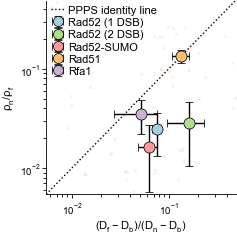

/var/folders/kp/rpw6x9gx71ncgf2hj3y5qc080000gn/T/ipykernel_85051/774366281.py:70: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


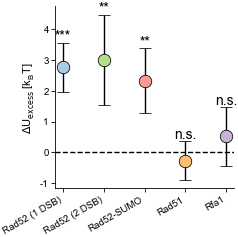

In [ ]:
colors = plt.cm.Paired(np.arange(0, len(res) * 2, 2))

# (A) Diffusivity-density plane.
fig, ax = plt.subplots(figsize=(2.55, 2.55))
for i, (name, array) in enumerate(res.items()):
    x, y = array[:, 0], array[:, 1]
    valid = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    ax.loglog(x[valid], y[valid], ".", alpha=0.15, color=colors[i])

    result = R[name]
    ax.errorbar(
        result["mx"],
        result["my"],
        xerr=result["sx"],
        yerr=result["sy"],
        fmt="o",
        ms=8,
        mec="k",
        ecolor="k",
        capsize=3,
        color=colors[i],
        label=PRETTY_NAMES[name],
    )

mean_values = [R[name][key] for name in res for key in ("mx", "my")]
axis_min = min(mean_values) / 3
axis_max = max(mean_values) * 3
ax.plot([axis_min, axis_max], [axis_min, axis_max], "k:", label="PPPS identity line")
ax.set_xlim(axis_min, axis_max)
ax.set_ylim(axis_min, axis_max)
ax.set_xlabel(r"$(D_f-D_b)/(D_n-D_b)$")
ax.set_ylabel(r"$\rho_n/\rho_f$")
ax.legend()
fig.tight_layout()
fig.savefig("diffusivity_density_plane.png", dpi=300, bbox_inches="tight")
plt.show()

# (B) Excess-energy confidence intervals.
names = list(res)
fig, ax = plt.subplots(figsize=(2.55, 2.55))
for i, name in enumerate(names):
    result = R[name]
    lower_error = result["m"] - result["ci"][0]
    upper_error = result["ci"][1] - result["m"]
    ax.errorbar(
        i,
        result["m"],
        yerr=[[lower_error], [upper_error]],
        fmt="o",
        ms=9,
        mec="k",
        ecolor="k",
        capsize=4,
        color=colors[i],
    )

    p_holm = result["p_holm"]
    significance = (
        "***" if p_holm < 1e-3
        else "**" if p_holm < 1e-2
        else "*" if p_holm < 0.05
        else "n.s."
    )
    ax.text(i, result["ci"][1] + 0.08, significance, ha="center", fontsize=10)

ax.axhline(0, color="k", lw=1, ls="--")
ax.set_xticks(range(len(names)))
ax.set_xticklabels([PRETTY_NAMES[name] for name in names], rotation=30, ha="right")
ax.set_ylabel(r"$\Delta U_{\mathrm{excess}}$ [$k_BT$]")
fig.tight_layout()
fig.savefig("excess_energy_CI_panel.png", dpi=300, bbox_inches="tight")
plt.show()